# Imports

In [ ]:
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import SparseLinear
from DenseMLP import DenseMLP
from SparseMLP import SparseMLP
from utils import get_dataloaders, train_model, evaluate
from visualization_utils import plot_accuracy_over_epochs, plot_training_time_comparison, create_training_time_table, create_accuracy_summary_table


# Loading Datasets

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# Use utils.get_dataloaders to fetch common datasets
train_loader, test_loader = get_dataloaders("MNIST", batch_size_train=128, batch_size_test=256, data_dir="./data")


# Dataset selection and helper
Use `dataset_name` to choose which dataset to load. Hyphenated names like `CIFAR-10` are normalized below.

In [5]:
# Helper to normalize names and load datasets
def normalize_dataset_name(name):
    n = name.lower().strip()
    # common aliases
    if 'cifar-10' in n or 'cifar10' in n or 'cifar_10' in n:
        return 'CIFAR10'
    if 'cifar-100' in n or 'cifar100' in n or 'cifar_100' in n:
        return 'CIFAR100'
    if 'fashion' in n and 'mnist' in n:
        return 'Fashion-MNIST'
    if 'kmnist' in n or 'k-mnist' in n:
        return 'KMNIST'
    if 'svhn' in n:
        return 'SVHN'
    if 'tiny' in n and 'imagenet' in n:
        return 'Tiny-ImageNet'
    if 'uci' in n or 'adult' in n:
        return 'UCI-Adult'
    if 'covertype' in n:
        return 'Covertype'
    # fallback: try raw name
    return name

# Example: change dataset_name to test others
dataset_name = 'CIFAR-10'
ds = normalize_dataset_name(dataset_name)
print('Loading dataset:', ds)
try:
    train_loader, test_loader = get_dataloaders(ds, batch_size_train=128, batch_size_test=256, data_dir='./data')
    xb,yb = next(iter(train_loader))
    print('train batch shape:', xb.shape, yb.shape)
except Exception as e:
    print('Loader error:', type(e).__name__, e)


Loading dataset: CIFAR10


100.0%


train batch shape: torch.Size([128, 3, 32, 32]) torch.Size([128])


# CIFAR CNN Dense and SparseLinear Testing
Small CNN backbone and swap the final fully-connected layers between standard `nn.Linear` and `SparseLinear` implementation.

## CIFAR10 Dataset Sanity test

In [6]:
from models import CIFARSmallCNN

# quick sanity check shapes (model now imported from models.py)
model_dense = CIFARSmallCNN(use_sparse=False)
model_sparse = CIFARSmallCNN(use_sparse=True, keep_ratio=0.6)
if 'train_loader' in globals():
    bx,by = next(iter(train_loader))
    print('input batch shape:', bx.shape)
    print('dense out:', model_dense(bx).shape)
    print('sparse out:', model_sparse(bx).shape)


input batch shape: torch.Size([128, 3, 32, 32])
dense out: torch.Size([128, 10])
sparse out: torch.Size([128, 10])


# Run a 1-epoch smoke training (CIFAR)
We'll do a single epoch for the dense and sparse CIFAR models to verify training works end-to-end.

In [ ]:
# Only run if CIFAR loaders loaded successfully
try:
    train_loader_c, test_loader_c = get_dataloaders('CIFAR10', batch_size_train=128, batch_size_test=256, data_dir='./data')
except Exception as e:
    print('CIFAR10 loader not available:', e)
    train_loader_c = None

if train_loader_c is not None:
    print('Training DENSE CIFAR model (1 epoch)...')
    dense = CIFARSmallCNN(use_sparse=False)
    dense_acc, dense_time = train_model(dense, train_loader_c, test_loader_c, epochs=1, lr=0.01)
    print('Dense CIFAR acc:', dense_acc)
    print('Dense CIFAR time:', dense_time)

    print('Training SPARSE CIFAR model (1 epoch)...')
    sparse = CIFARSmallCNN(use_sparse=True, keep_ratio=0.6)
    sparse_acc, sparse_time = train_model(sparse, train_loader_c, test_loader_c, epochs=1, lr=0.01)
    print('Sparse CIFAR acc:', sparse_acc)
    print('Sparse CIFAR time:', sparse_time)


Training DENSE CIFAR model (1 epoch)...
Epoch 1 | Loss: 1.7974 | Accuracy: 0.4367
Dense CIFAR acc: [0.4367]
Training SPARSE CIFAR model (1 epoch)...
Epoch 1 | Loss: 1.7967 | Accuracy: 0.4582
Sparse CIFAR acc: [0.4582]


# Full CIFAR-10 Training: Dense vs Sparse
Train dense and sparse CNN models for multiple epochs on CIFAR-10 to compare accuracy and training time.

In [9]:
# Full CIFAR-10 training with multiple keep ratios
try:
    train_loader_full, test_loader_full = get_dataloaders('CIFAR10', batch_size_train=128, batch_size_test=256, data_dir='./data')
except Exception as e:
    print('CIFAR10 loader error:', e)
    train_loader_full = None

if train_loader_full is not None:
    # Train dense CIFAR model
    print('\n' + '='*60)
    print('Training DENSE CIFAR-10 CNN (5 epochs)...')
    print('='*60)
    dense_cifar = CIFARSmallCNN(use_sparse=False)
    dense_cifar_acc, dense_cifar_time = train_model(dense_cifar, train_loader_full, test_loader_full, epochs=5, lr=0.01)
    print(f'\nDense CIFAR-10 Final Accuracy: {dense_cifar_acc[-1]:.4f}')
    print(f'Dense CIFAR-10 Training Time: {dense_cifar_time:.2f}s')

    # Train sparse CIFAR models with different keep ratios
    cifar_keep_ratios = [1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4]
    cifar_sparse_accuracies = []
    cifar_sparse_times = []

    for keep_ratio in cifar_keep_ratios:
        print(f'\n' + '='*60)
        print(f'Training SPARSE CIFAR-10 CNN ({keep_ratio*100:.0f}% Keep Ratio, 5 epochs)...')
        print('='*60)
        sparse_cifar = CIFARSmallCNN(use_sparse=True, keep_ratio=keep_ratio)
        sparse_acc, sparse_time = train_model(sparse_cifar, train_loader_full, test_loader_full, epochs=5, lr=0.01)
        cifar_sparse_accuracies.append(sparse_acc)
        cifar_sparse_times.append(sparse_time)
        print(f'Sparse ({keep_ratio*100:.0f}%) Final Accuracy: {sparse_acc[-1]:.4f}')
        print(f'Sparse ({keep_ratio*100:.0f}%) Training Time: {sparse_time:.2f}s')



Training DENSE CIFAR-10 CNN (5 epochs)...
Epoch 1 | Loss: 1.7927 | Accuracy: 0.4559
Epoch 2 | Loss: 1.4381 | Accuracy: 0.5060
Epoch 3 | Loss: 1.3142 | Accuracy: 0.5618
Epoch 4 | Loss: 1.2027 | Accuracy: 0.5981
Epoch 5 | Loss: 1.1044 | Accuracy: 0.6142

Dense CIFAR-10 Final Accuracy: 0.6142
Dense CIFAR-10 Training Time: 342.24s

Training SPARSE CIFAR-10 CNN (100% Keep Ratio, 5 epochs)...
Epoch 1 | Loss: 1.6923 | Accuracy: 0.4970
Epoch 2 | Loss: 1.3547 | Accuracy: 0.5402
Epoch 3 | Loss: 1.2166 | Accuracy: 0.5884
Epoch 4 | Loss: 1.1063 | Accuracy: 0.6234
Epoch 5 | Loss: 1.0166 | Accuracy: 0.6515
Sparse (100%) Final Accuracy: 0.6515
Sparse (100%) Training Time: 344.35s

Training SPARSE CIFAR-10 CNN (90% Keep Ratio, 5 epochs)...
Epoch 1 | Loss: 1.7216 | Accuracy: 0.4762
Epoch 2 | Loss: 1.3740 | Accuracy: 0.5437
Epoch 3 | Loss: 1.2392 | Accuracy: 0.5747
Epoch 4 | Loss: 1.1271 | Accuracy: 0.6020
Epoch 5 | Loss: 1.0457 | Accuracy: 0.6290
Sparse (90%) Final Accuracy: 0.6290
Sparse (90%) Traini

## CIFAR10 Visualization

In [ ]:
if 'cifar_sparse_accuracies' in globals():
    plot_accuracy_over_epochs(dense_cifar_acc, cifar_keep_ratios, cifar_sparse_accuracies, title='CIFAR-10: Accuracy over Epochs')


In [ ]:
if 'cifar_sparse_times' in globals():
    plot_training_time_comparison(cifar_keep_ratios, cifar_sparse_times, dense_cifar_time, title='CIFAR-10: Training Time Comparison')


# MNIST Dense and SparseLinear Testing

## Train Dense Model

In [ ]:
dense_model = DenseMLP()

print("\nDense Training")
dense_acc, dense_time = train_model(dense_model, train_loader, test_loader, epochs=5)

print("\nDense Results")
print("Final Accuracy:", dense_acc[-1])
print("Time:", dense_time)


Dense Training
Epoch 1 | Loss: 0.3325 | Accuracy: 0.9507
Epoch 2 | Loss: 0.1102 | Accuracy: 0.9715
Epoch 3 | Loss: 0.0713 | Accuracy: 0.9741
Epoch 4 | Loss: 0.0553 | Accuracy: 0.9718
Epoch 5 | Loss: 0.0428 | Accuracy: 0.9768

Dense Results
Final Accuracy: 0.9768
Time: 6.410501956939697


## Train Sparse Model

In [ ]:
list_of_keep_ratios = [1, .95, .9, .85, .8, .75, .7, .65, .6, .55, .5, .45, .4,]
list_of_list_of_sparse_accuracies = []
list_of_sparse_times = []

for keep_ratio in list_of_keep_ratios:
    
    sparse_model = SparseMLP(
        keep_ratio=keep_ratio
    )

    print(f"\nSparse Training: {keep_ratio*100:.0f}% Keep Ratio")

    sparse_acc, sparse_time = train_model(sparse_model, train_loader, test_loader, epochs=5)

    list_of_list_of_sparse_accuracies.append(sparse_acc)
    list_of_sparse_times.append(sparse_time)

    print(f"\nSparse Results: {keep_ratio*100:.0f}% Keep Ratio")
    print("Final Accuracy:", sparse_acc[-1])
    print("Time:", sparse_time)


Sparse Training: 100% Keep Ratio
Epoch 1 | Loss: 0.2599 | Accuracy: 0.9665
Epoch 2 | Loss: 0.0989 | Accuracy: 0.9727
Epoch 3 | Loss: 0.0685 | Accuracy: 0.9764
Epoch 4 | Loss: 0.0488 | Accuracy: 0.9754
Epoch 5 | Loss: 0.0394 | Accuracy: 0.9771

Sparse Results: 100% Keep Ratio
Final Accuracy: 0.9771
Time: 7.55635929107666

Sparse Training: 99% Keep Ratio
Epoch 1 | Loss: 0.2661 | Accuracy: 0.9619
Epoch 2 | Loss: 0.0986 | Accuracy: 0.9715
Epoch 3 | Loss: 0.0695 | Accuracy: 0.9724
Epoch 4 | Loss: 0.0522 | Accuracy: 0.9760
Epoch 5 | Loss: 0.0403 | Accuracy: 0.9759

Sparse Results: 99% Keep Ratio
Final Accuracy: 0.9759
Time: 7.48343300819397

Sparse Training: 98% Keep Ratio
Epoch 1 | Loss: 0.2722 | Accuracy: 0.9637
Epoch 2 | Loss: 0.0986 | Accuracy: 0.9707
Epoch 3 | Loss: 0.0689 | Accuracy: 0.9716
Epoch 4 | Loss: 0.0522 | Accuracy: 0.9775
Epoch 5 | Loss: 0.0418 | Accuracy: 0.9782

Sparse Results: 98% Keep Ratio
Final Accuracy: 0.9782
Time: 7.524281740188599

Sparse Training: 95% Keep Ratio
E

# MNIST Visualization

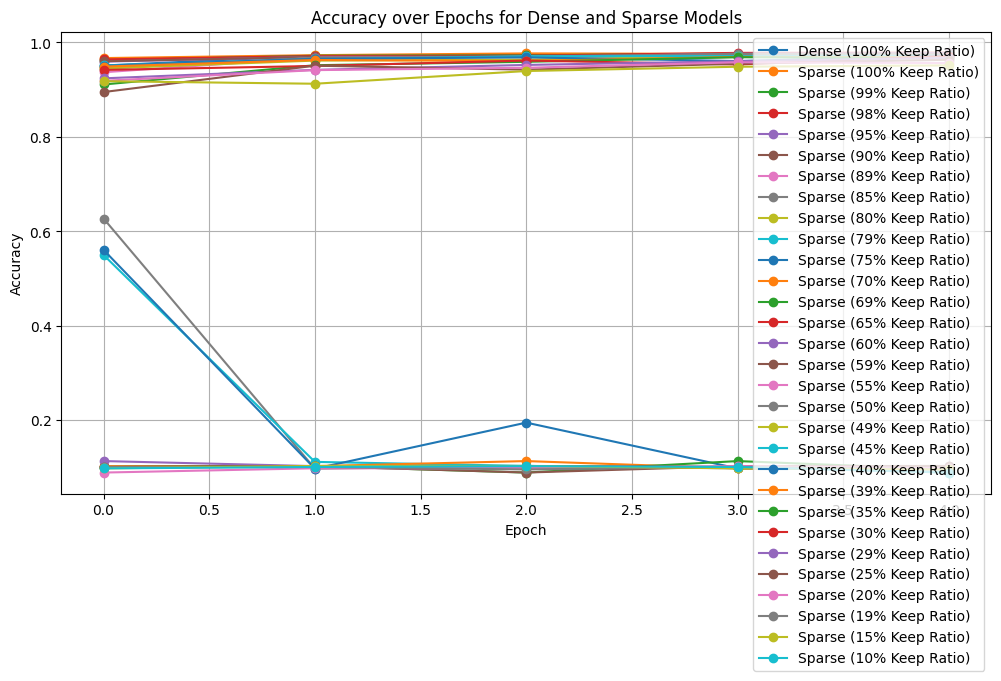

In [ ]:
if 'dense_acc' in globals() and 'list_of_sparse_accuracies' in globals():
    plot_accuracy_over_epochs(dense_acc, list_of_keep_ratios, list_of_list_of_sparse_accuracies)


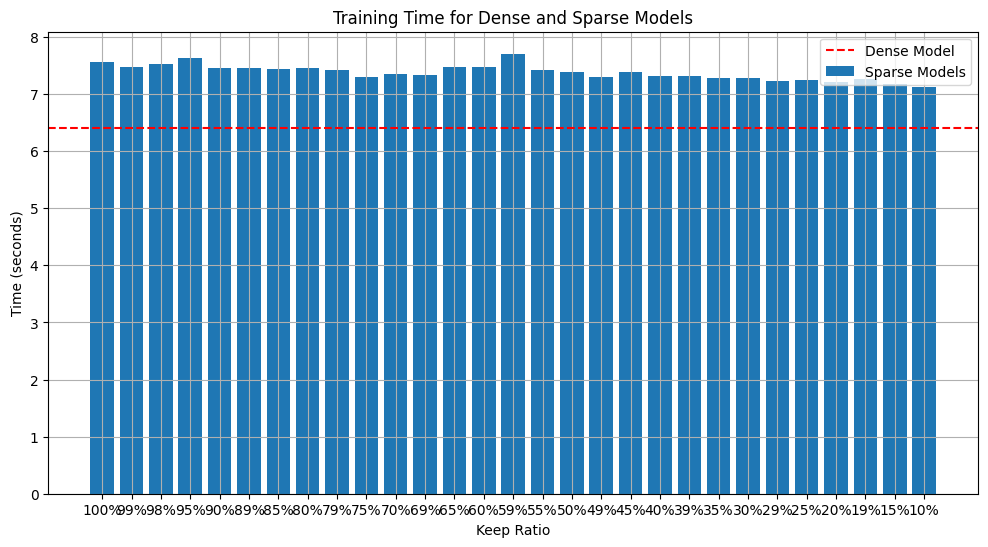

In [ ]:
if 'dense_acc' in globals() and 'list_of_sparse_times' in globals():
    plot_training_time_comparison(list_of_keep_ratios, list_of_sparse_times, dense_time)


In [ ]:
if 'dense_acc' in globals() and 'list_of_sparse_accuracies' in globals():
    print('\n' + '='*60)
    print('MNIST Testing Results')
    print('='*60)
    print('\nAccuracy Summary:')
    acc_summary = create_accuracy_summary_table(list_of_keep_ratios, list_of_list_of_sparse_accuracies, dense_acc)
    print(acc_summary.to_string(index=False))
    print('\nTraining Time Summary:')
    time_summary = create_training_time_table(list_of_keep_ratios, list_of_sparse_times, dense_time)
    print(time_summary.to_string(index=False))

if 'cifar_sparse_accuracies' in globals():
    print('\n' + '='*60)
    print('CIFAR-10 Testing Results')
    print('='*60)
    print('\nAccuracy Summary:')
    cifar_acc_summary = create_accuracy_summary_table(cifar_keep_ratios, cifar_sparse_accuracies, dense_cifar_acc)
    print(cifar_acc_summary.to_string(index=False))
    print('\nTraining Time Summary:')
    cifar_time_summary = create_training_time_table(cifar_keep_ratios, cifar_sparse_times, dense_cifar_time)
    print(cifar_time_summary.to_string(index=False))


      Keep Ratio  Training Time (seconds)
0           100%                 7.556359
1            99%                 7.483433
2            98%                 7.524282
3            95%                 7.632997
4            90%                 7.449646
5            89%                 7.466193
6            85%                 7.445854
7            80%                 7.460744
8            79%                 7.414507
9            75%                 7.297827
10           70%                 7.345308
11           69%                 7.343911
12           65%                 7.481729
13           60%                 7.479159
14           59%                 7.707921
15           55%                 7.423846
16           50%                 7.393652
17           49%                 7.297193
18           45%                 7.386063
19           40%                 7.312433
20           39%                 7.325702
21           35%                 7.288368
22           30%                 7